In [2]:
# Cell 1: Setup & Imports
import torch
import torch.nn as nn
from torchvision import transforms, models
from torchvision.datasets import EuroSAT
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from pathlib import Path
import warnings

# Hide annoying download warnings
warnings.filterwarnings("ignore") 

# Setup Device
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda:0


In [3]:
# Cell 2: Locate Data & Replicate the Split
print("Locating local EuroSAT Dataset...")
dataset_path = Path('./data/eurosat/2750')
image_paths = sorted(list(dataset_path.glob('**/*.jpg')))

# Define classes and map them to integers
classes = ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 
           'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
class_to_idx = {cls_name: i for i, cls_name in enumerate(classes)}
numeric_labels = [class_to_idx[path.parent.name] for path in image_paths]

# Replicate the exact 70/15/15 split
X_train, X_temp, y_train, y_temp = train_test_split(
    image_paths, numeric_labels, test_size=0.3, random_state=42, stratify=numeric_labels
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)
print(f"Total isolated test images: {len(X_test)}")

Locating local EuroSAT Dataset...
Total isolated test images: 4050


In [4]:
# Cell 3: Custom Dataset & Dataloader
class EuroSATDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform
        
    def __len__(self): 
        return len(self.image_paths)
        
    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("RGB")
        if self.transform: 
            image = self.transform(image)
        return image, self.labels[idx]

# Apply preprocessing transformations
test_transform = transforms.Compose([
    transforms.Resize((64, 64)), 
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Create the loader that feeds images to the model in batches of 32
test_loader = DataLoader(EuroSATDataset(X_test, y_test, transform=test_transform), batch_size=32, shuffle=False)
print("Dataloader ready.")

Dataloader ready.


In [5]:
# Cell 4: Load Trained Models
import torch.nn as nn


class IdentityBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.relu = nn.ReLU()
        self.identity = nn.Sequential(
            nn.Conv2d(channels, channels, 3, 1, 1),
            nn.BatchNorm2d(channels),
            nn.ReLU(),
            nn.Conv2d(channels, channels, 3, 1, 1),
            nn.BatchNorm2d(channels)
        )
    def forward(self, x):
        residual = x
        x = self.identity(x)
        x += residual
        x = self.relu(x)
        return x

class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.relu = nn.ReLU()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, 2, 1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
            nn.Conv2d(out_channels, out_channels, 3, 1, 1),
            nn.BatchNorm2d(out_channels)
        )
        self.shortcut = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 1, 2, 0),
            nn.BatchNorm2d(out_channels)
        )
    def forward(self, x):
        residual = self.shortcut(x)
        x = self.conv(x)
        x += residual
        x = self.relu(x)
        return x

class Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.input = nn.Sequential(
            nn.Conv2d(3, 64, 3, 1, 1),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )
        self.stage1 = nn.Sequential(IdentityBlock(64), IdentityBlock(64))
        self.stage2 = nn.Sequential(ConvBlock(64, 128), IdentityBlock(128))
        self.stage3 = nn.Sequential(ConvBlock(128, 256), IdentityBlock(256))
        self.stage4 = nn.Sequential(ConvBlock(256, 512), IdentityBlock(512))
        self.avgPool = nn.AvgPool2d(8)
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 10),
        )
    def forward(self, x):
        x = self.input(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.stage4(x)
        x = self.avgPool(x)
        x = self.fc(x)
        return x

print("Loading Models...")

# 1. Load Custom Baseline
baseline = Model()
baseline.load_state_dict(torch.load("AI-For-Space/Notebooks/Baseline Model.pth", map_location=device))
baseline = baseline.to(device).eval()
print("Baseline loaded successfully.")

# 2. Load Standard ResNet50
resnet50_std = models.resnet50(weights=None)
resnet50_std.fc = nn.Linear(resnet50_std.fc.in_features, 10)
resnet50_std.load_state_dict(torch.load("AI-For-Space/Notebooks/Best_ResNet50_Model.pth", map_location=device))
resnet50_std = resnet50_std.to(device).eval()
print("Standard ResNet50 loaded successfully.")

# 3. Load Augmented ResNet50 
resnet50_aug = models.resnet50(weights=None)
resnet50_aug.fc = nn.Linear(resnet50_aug.fc.in_features, 10)
resnet50_aug.load_state_dict(torch.load("Best_Augmented_ResNet50_Model.pth", map_location=device))
resnet50_aug = resnet50_aug.to(device).eval()
print("Augmented ResNet50 loaded successfully.")

Loading Models...
Baseline loaded successfully.
Standard ResNet50 loaded successfully.
Augmented ResNet50 loaded successfully.


In [6]:
# Cell 5: Evaluation Loop

def evaluate_model(model, loader):
    y_true, y_pred = [], []
    with torch.no_grad(): # Disable gradients to save memory and speed up testing
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
            
    return y_true, y_pred

print("Gathering predictions for ResNet18 (Baseline)...")
y_true_base, y_pred_base = evaluate_model(baseline, test_loader)

print("Gathering predictions for Standard ResNet50...")
y_true_r50_std, y_pred_r50_std = evaluate_model(resnet50_std, test_loader)

print("Gathering predictions for Augmented ResNet50...")
y_true_r50_aug, y_pred_r50_aug = evaluate_model(resnet50_aug, test_loader)

print("All predictions gathered successfully! Ready for plotting.")

Gathering predictions for ResNet18 (Baseline)...
Gathering predictions for Standard ResNet50...
Gathering predictions for Augmented ResNet50...
All predictions gathered successfully! Ready for plotting.



ResNet18 (Baseline) Test Accuracy:    96.84%
Standard ResNet50 Test Accuracy:      96.89%
Augmented ResNet50 Test Accuracy:     97.65%

--- ResNet18 (Baseline) Classification Report ---
                      precision    recall  f1-score   support

          AnnualCrop       0.95      0.92      0.94       450
              Forest       0.98      1.00      0.99       450
HerbaceousVegetation       0.94      0.98      0.96       450
             Highway       0.96      0.98      0.97       375
          Industrial       0.99      0.98      0.99       375
             Pasture       0.98      0.97      0.97       300
       PermanentCrop       0.95      0.90      0.93       375
         Residential       0.98      0.99      0.99       450
               River       0.97      0.96      0.96       375
             SeaLake       1.00      0.99      0.99       450

            accuracy                           0.97      4050
           macro avg       0.97      0.97      0.97      4050
     

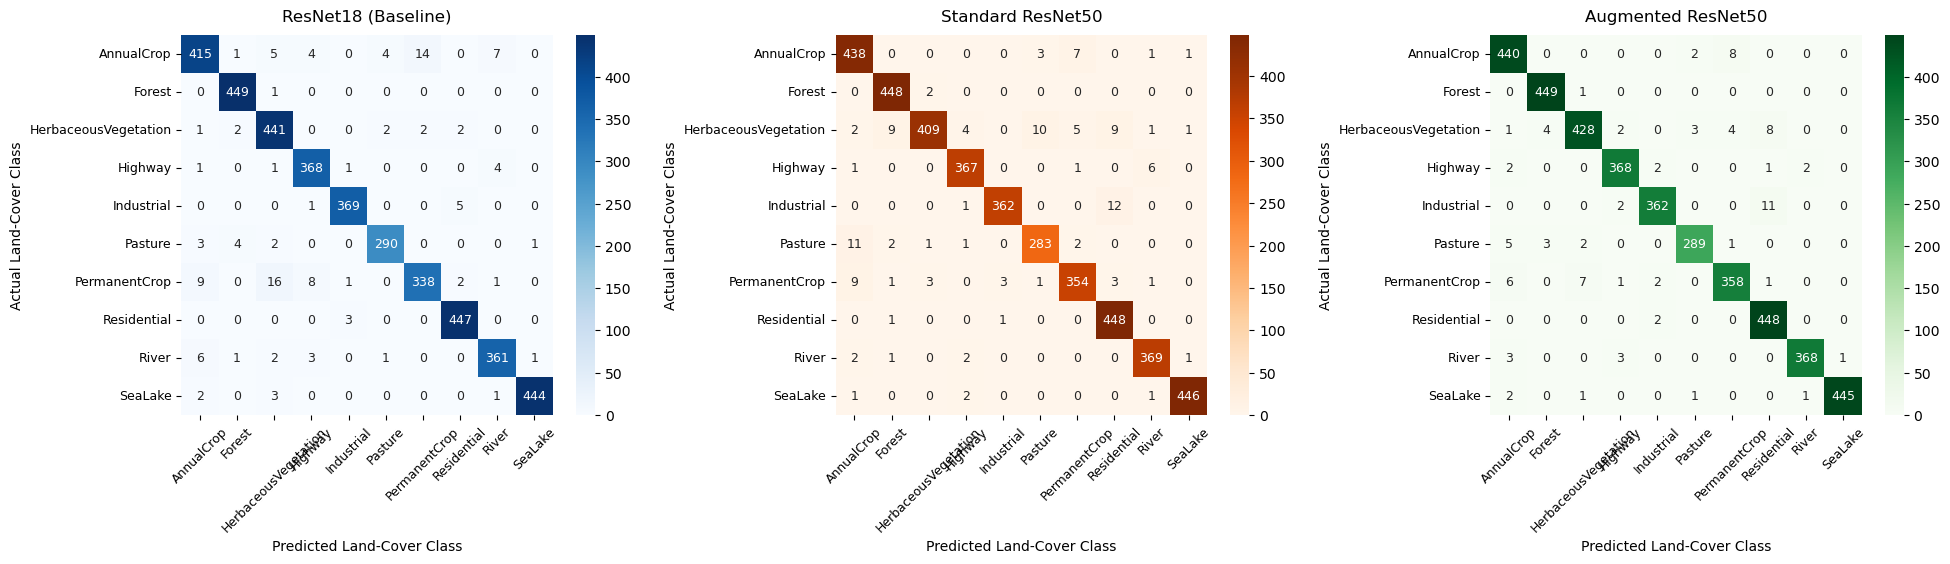

In [7]:
# Cell 6: Metrics & Visualizations

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Print Overall Accuracies
print("\n" + "="*60)
print(f"ResNet18 (Baseline) Test Accuracy:    {accuracy_score(y_true_base, y_pred_base)*100:.2f}%")
print(f"Standard ResNet50 Test Accuracy:      {accuracy_score(y_true_r50_std, y_pred_r50_std)*100:.2f}%")
print(f"Augmented ResNet50 Test Accuracy:     {accuracy_score(y_true_r50_aug, y_pred_r50_aug)*100:.2f}%")
print("="*60 + "\n")

# 2. Print Classification Reports (for F1-Scores)
print("--- ResNet18 (Baseline) Classification Report ---")
print(classification_report(y_true_base, y_pred_base, target_names=classes))

print("\n--- Standard ResNet50 Classification Report ---")
print(classification_report(y_true_r50_std, y_pred_r50_std, target_names=classes))

print("\n--- Augmented ResNet50 Classification Report ---")
print(classification_report(y_true_r50_aug, y_pred_r50_aug, target_names=classes))

# 3. Plot Confusion Matrices Side-by-Side (1 Row, 3 Columns)
# REDUCED FIGSIZE HERE: Changed from (24, 7) to (20, 6)
fig, ax = plt.subplots(1, 3, figsize=(20, 6))

# ResNet18 Matrix (Blue)
sns.heatmap(confusion_matrix(y_true_base, y_pred_base), annot=True, fmt='d', cmap='Blues', 
            xticklabels=classes, yticklabels=classes, ax=ax[0], annot_kws={"size": 9})
ax[0].set_title("ResNet18 (Baseline)", fontsize=12, pad=10)
ax[0].set_ylabel('Actual Land-Cover Class', fontsize=10)
ax[0].set_xlabel('Predicted Land-Cover Class', fontsize=10)
ax[0].tick_params(axis='x', rotation=45, labelsize=9)
ax[0].tick_params(axis='y', labelsize=9)

# Standard ResNet50 Matrix (Oranges)
sns.heatmap(confusion_matrix(y_true_r50_std, y_pred_r50_std), annot=True, fmt='d', cmap='Oranges', 
            xticklabels=classes, yticklabels=classes, ax=ax[1], annot_kws={"size": 9})
ax[1].set_title("Standard ResNet50", fontsize=12, pad=10)
ax[1].set_ylabel('Actual Land-Cover Class', fontsize=10)
ax[1].set_xlabel('Predicted Land-Cover Class', fontsize=10)
ax[1].tick_params(axis='x', rotation=45, labelsize=9)
ax[1].tick_params(axis='y', labelsize=9)

# Augmented ResNet50 Matrix (Greens)
sns.heatmap(confusion_matrix(y_true_r50_aug, y_pred_r50_aug), annot=True, fmt='d', cmap='Greens', 
            xticklabels=classes, yticklabels=classes, ax=ax[2], annot_kws={"size": 9})
ax[2].set_title("Augmented ResNet50", fontsize=12, pad=10)
ax[2].set_ylabel('Actual Land-Cover Class', fontsize=10)
ax[2].set_xlabel('Predicted Land-Cover Class', fontsize=10)
ax[2].tick_params(axis='x', rotation=45, labelsize=9)
ax[2].tick_params(axis='y', labelsize=9)

# Added tight_layout with a pad to ensure nothing gets cut off
plt.tight_layout(pad=2.0)
plt.show()